# Quantum data example in Kappen (2018)
This notebook reproduces the example in Section 4 of [Kappen](https://arxiv.org/abs/1803.11278)

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))  # go up two levels (from numerics to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# # Ensure packages are installed
# for pkg in [
#     "PauliPropagation", "Plots", "LinearAlgebra", "ProgressMeter", "Distributions",
#     "Random", "Optimisers", "ReverseDiff", "MAT", "BenchmarkTools", "IterTools", "StatsBase", "LaTeXStrings", "Measures"
# ]
#     Pkg.add(pkg)
# end

In [3]:
# Load all packages
using PauliSampling, PauliPropagation, Plots, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures

In [6]:
# define number of sites == number of qubits (each site is a 2-level system)
n = 6 ## change this to 10 to reproduce the paper results

6

## Target state

The quantum state we set up to learn using a QBM is a thermal state (for three different temperatures) from the Hamiltonian of the 1D Heisenberg model with nearest-neighbors interactions, isotropic couplings and zero single-site fields. We report here the full Eq. (13) of the [paper](https://arxiv.org/abs/1803.11278):
\begin{equation}
H = \sum_{i=1}^{n} \sum_{k = x, y, z} w_i^{k} \sigma_i^{k}
    + \sum_{i=1}^{n} \sum_{j > i}^{n} \sum_{k = x, y, z} w_{ij}^{k} \sigma_i^{k} \sigma_j^{k},
\end{equation}
where $\sigma_j^{k}$ are Pauli operators on site $j$ and $n$ is the total number of sites.

The target state is generated with the Hamiltonian where
$$
w_{ij}^{x,y,z} = 1 \text{ for nearest neighbors,} \quad 
w_{ij}^{x,y,z} = 0 \text{ otherwise, and } w_i^{k} = 0.
$$


### Hamiltonian 
For this example, we work under the (simplifying) assumption that each spin direction will have a separate parameter, but that the interaction in a fixed spin direction is isotropic along the spin chain of 
sites (we also include periodic boundary conditions). This amounts to the Hamiltonian of the `XYZ` Heisenberg model, but when the `x`, `y`, and `z` couplings are the same, then it is the `XXX` Heisenberg model:

In [4]:
# Fix the parameters of the hamiltonian:
# - 3 parameters for the nearest-neighbors terms
# - 3 parameters for the single-site fields
target_wij_xyz = (1.0, 1.0, 1.0)
target_wi_xyz = (0.0, 0.0, 0.0)
@printf("Spin interaction used to create target state: %s\n", target_wij_xyz)
@printf("Field value used to create target state: %s\n", target_wi_xyz)

Spin interaction used to create target state: (1.0, 1.0, 1.0)
Field value used to create target state: (0.0, 0.0, 0.0)


In [15]:
j = 4 .* target_wij_xyz
b = 2 .* target_wi_xyz
target_xxx = makehamiltonian(n; wi_xyz=b, wij_xyz=j, periodic=true)

18-element Vector{PauliString}:
 PauliString(nqubits: 6, 1.0 * XXIIII)
 PauliString(nqubits: 6, 1.0 * IXXIII)
 PauliString(nqubits: 6, 1.0 * IIXXII)
 PauliString(nqubits: 6, 1.0 * IIIXXI)
 PauliString(nqubits: 6, 1.0 * IIIIXX)
 PauliString(nqubits: 6, 1.0 * XIIIIX)
 PauliString(nqubits: 6, 1.0 * YYIIII)
 PauliString(nqubits: 6, 1.0 * IYYIII)
 PauliString(nqubits: 6, 1.0 * IIYYII)
 PauliString(nqubits: 6, 1.0 * IIIYYI)
 PauliString(nqubits: 6, 1.0 * IIIIYY)
 PauliString(nqubits: 6, 1.0 * YIIIIY)
 PauliString(nqubits: 6, 1.0 * ZZIIII)
 PauliString(nqubits: 6, 1.0 * IZZIII)
 PauliString(nqubits: 6, 1.0 * IIZZII)
 PauliString(nqubits: 6, 1.0 * IIIZZI)
 PauliString(nqubits: 6, 1.0 * IIIIZZ)
 PauliString(nqubits: 6, 1.0 * ZIIIIZ)

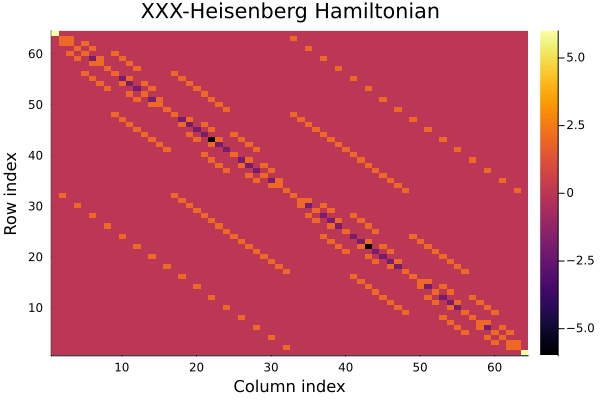

In [16]:
target_xxx_matrix = paulistringtomatrix(target_xxx)

heatmap(reverse(real(target_xxx_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="XXX-Heisenberg Hamiltonian"
        )

### Density matrix

The paper generates a density matrix from the `XXX ` Hamiltonian at 3 different temperatures $T = 1/\beta$
, with $\beta =1,2,∞$

In [18]:
targert_circuit, θ = paulistringtocircuit(target_xxx)
num_layers = 100
max_weight = n
min_abs_coeff = 1e-20;

In [19]:
target_beta1 = 1.0

target_eta_beta1 = makethermalstate(n, targert_circuit, θ, num_layers;
                                  beta=target_beta1, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)

target_eta_beta1_matrix = paulistringtomatrix(target_eta_beta1);

In [21]:
target_beta2 = 2.0

target_eta_beta2 = makethermalstate(n, targert_circuit, θ, num_layers;
                                  beta=target_beta2, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)

target_eta_beta2_matrix = paulistringtomatrix(target_eta_beta2);

In [22]:
target_beta∞ = Inf


Inf

In [38]:
target_beta∞ = 60.

target_eta_beta∞ = makethermalstate(n, targert_circuit, θ, num_layers;
                                  beta=target_beta∞, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)

target_eta_beta∞_matrix = paulistringtomatrix(target_eta_beta∞);

## Quantum Boltzmann Machine model

Following the paper we now define the QBM based on the same `XYZ` Heisenberg Hamiltonian used to define the target state. We let the 3 parameters for each spin direction to have arbitrary values.

In [41]:
# parameters to learn. Set initial values at random
rng = MersenneTwister()  
j = Tuple(randn(rng, 3))        
b = Tuple(randn(rng, 3))
@printf("Spin interaction: %s\n", j)
@printf("Field value: %s\n", b)

Spin interaction: (-1.2492369132642849, -0.13911732419361522, -0.5428664680754258)
Field value: (-0.17470234242029553, 0.8018117526615792, -0.6151223076563331)


In [ ]:
qbm_xyz = makehamiltonian(n; wi_xyz=b, wij_xyz=j, periodic=true);


36-element Vector{PauliString}:
 PauliString(nqubits: 6, -0.087351 * XIIIII)
 PauliString(nqubits: 6, -0.087351 * IXIIII)
 PauliString(nqubits: 6, -0.087351 * IIXIII)
 PauliString(nqubits: 6, -0.087351 * IIIXII)
 PauliString(nqubits: 6, -0.087351 * IIIIXI)
 PauliString(nqubits: 6, -0.087351 * IIIIIX)
 PauliString(nqubits: 6, 0.40091 * YIIIII)
 PauliString(nqubits: 6, 0.40091 * IYIIII)
 PauliString(nqubits: 6, 0.40091 * IIYIII)
 PauliString(nqubits: 6, 0.40091 * IIIYII)
 ⋮
 PauliString(nqubits: 6, -0.034779 * IIIYYI)
 PauliString(nqubits: 6, -0.034779 * IIIIYY)
 PauliString(nqubits: 6, -0.034779 * YIIIIY)
 PauliString(nqubits: 6, -0.13572 * ZZIIII)
 PauliString(nqubits: 6, -0.13572 * IZZIII)
 PauliString(nqubits: 6, -0.13572 * IIZZII)
 PauliString(nqubits: 6, -0.13572 * IIIZZI)
 PauliString(nqubits: 6, -0.13572 * IIIIZZ)
 PauliString(nqubits: 6, -0.13572 * ZIIIIZ)

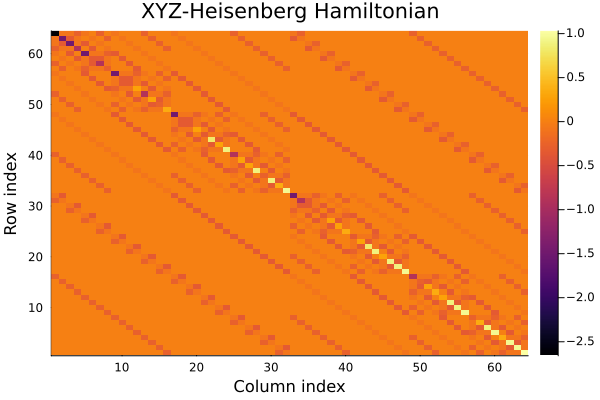

In [43]:
qbm_xyz_matrix = paulistringtomatrix(qbm_xyz)

heatmap(reverse(real(qbm_xyz_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="XYZ-Heisenberg Hamiltonian"
        )

### Gibbs state
The corresponding Gibbs state for this initial Hamiltonian is
$$\rho_\theta = \frac{e^{H_\theta}}{Z}$$

In [44]:
trial_circuit, trial_θ = paulistringtocircuit(qbm_xyz)
num_layers = 100
max_weight = n
min_abs_coeff = 1e-20
beta = -1.0

rho_qbm = makethermalstate(n, trial_circuit, trial_θ, num_layers;
                                  beta=beta, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)

rho_qbm_matrix = paulistringtomatrix(rho_qbm);

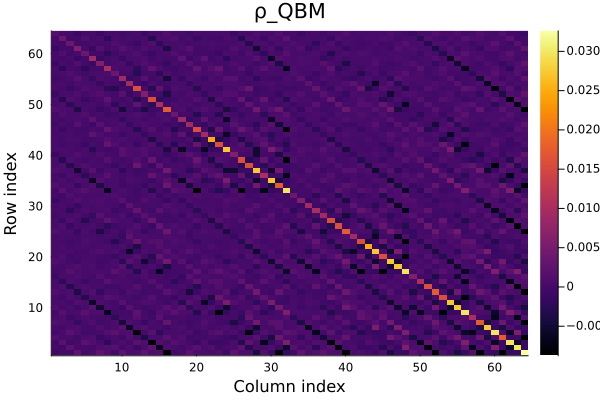

In [45]:
heatmap(reverse(real(rho_qbm_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="ρ_QBM"
        )

## Training of the QBM


In [51]:
target_probs_beta1 = computesymmetriceigenvalues(target_eta_beta1_matrix)
target_probs_beta1 = clamp.(target_probs_beta1, 1e-300, Inf);

In [ ]:
# learning rate
gamma = 0.2
# number of epochs
epochs = 2000

In [46]:
gradients = computegradient(qbm_xyz, target_eta_beta1, rho_qbm)
println("Gradients: ", gradients)

Gradients: [0.02275407921842661, 0.022754079218426548, 0.02275407921842661, 0.022754079218426565, 0.0227540792184265, 0.022754079218426572, -0.1620521005965422, -0.16205210059654204, -0.1620521005965426, -0.16205210059654254, -0.1620521005965422, -0.1620521005965421, 0.1063545162648965, 0.10635451626489678, 0.10635451626489621, 0.10635451626489646, 0.1063545162648964, 0.10635451626489681, -0.08353433608453126, -0.08353433608453131, -0.08353433608453116, -0.08353433608453122, -0.08353433608453124, -0.08353433608453129, -0.1625361335996232, -0.1625361335996232, -0.1625361335996231, -0.16253613359962296, -0.16253613359962304, -0.16253613359962304, -0.13337490727577897, -0.13337490727577897, -0.1333749072757789, -0.13337490727577883, -0.13337490727577886, -0.133374907275779]


In [ ]:
# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-6
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

new_params = rand(length(qbm_xyz))

epochs = 200

for i in 1:epochs

    # create qbm hamiltonian
    qbm_xyz = makehamiltonian(n; coeffs=new_params)
    qbm_xyz_matrix = paulistringtomatrix(qbm_xyz)
    push!(qre_hist, computequantumrelativeentropy(target_eta_beta1_matrix, target_probs_beta1, qbm_xyz_matrix))

    # create qbm state
    circuit, theta = paulistringtocircuit(qbm_xyz)
    num_layers = 100
    beta = -1.
    max_weight = n
    min_abs_coeff = 1e-10
    rho = makethermalstate(n, circuit, theta, num_layers;
                                    beta=beta, max_weight=max_weight,
                                    min_abs_coeff=min_abs_coeff)
    rho_matrix = paulistringtomatrix(rho)

    # grad and update
    grads = computegradient(qbm_xyz, target_eta_beta1, rho)
    push!(grad_hist, abs.(grads))
    new_params = gradientdescentstep(new_params, grads, gamma)

    # print diagnostic
    if (i % 10) == 0
        @printf("Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("Max abs gradient: %.6f\n", maximum(grad_hist[end]))
    end
    if maximum(grad_hist[end]) < epsilon
        println("Max gradient smaller than precision")
        break
    end
end 